# 解釋三種模型是如何進行決策的
用 SHAP 方法來進行解釋

## 環境建置
1. 載入所需套件 (Pandas, Scikit-learn, XGBoost, TensorFlow, 以及 SHAP)。
2. 讀取測試集。
3. 載入三種模型。

In [1]:
from pathlib import Path
import pandas as pd
import joblib
import yaml
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
import shap
import numpy as np
import matplotlib.pyplot as plt

# 設定路徑與讀取設定
PROJECT_ROOT = Path("..")
with open(PROJECT_ROOT / "config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

DATA_DIR = PROJECT_ROOT / config['data']['processed_dir']
MODEL_DIR = PROJECT_ROOT / 'models'

# 1. 讀取三種模型對應的測試集
rf_test_df = pd.read_csv(DATA_DIR / "rf_test.csv")
X_test_rf = rf_test_df.drop(columns=["default_flag"])
y_test_rf = rf_test_df["default_flag"]

xgb_test_df = pd.read_csv(DATA_DIR / "xgb_test.csv")
X_test_xgb = xgb_test_df.drop(columns=["default_flag"])
y_test_xgb = xgb_test_df["default_flag"]

dnn_test_df = pd.read_csv(DATA_DIR / "dnn_test.csv")
X_test_dnn = dnn_test_df.drop(columns=["default_flag"])
y_test_dnn = dnn_test_df["default_flag"]

# 2. 載入三種模型
rf_model = joblib.load(MODEL_DIR / "rf_model.joblib")
xgb_model = joblib.load(MODEL_DIR / "xgb_model.joblib")
dnn_model = tf.keras.models.load_model(MODEL_DIR / "dnn_model.keras")

ModuleNotFoundError: No module named 'shap'

## 1. 隨機森林 (Random Forest) 的 SHAP 解釋

In [ ]:
# 初始化 RF TreeExplainer
explainer_rf = shap.TreeExplainer(rf_model)

# 隨機抽取 500 筆測試集樣本以進行解釋（加速計算）
X_sample_rf = X_test_rf.sample(n=500, random_state=42)
shap_values_rf = explainer_rf(X_sample_rf)

# RandomForestClassifier 的輸出為各類別的機率 [prob_0, prob_1]
# 我們需要取對應到違約 (class 1) 的 SHAP 值
if len(shap_values_rf.shape) == 3 and shap_values_rf.shape[-1] == 2:
    shap_values_rf = shap_values_rf[..., 1]

# 繪製條形圖 (Bar Plot) - 全局特徵重要性
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_rf)

# 繪製蜂巢圖 (Beeswarm Plot) - 特徵高低值對決策的影響
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_rf)

## 2. XGBoost 的 SHAP 解釋

In [ ]:
# 初始化 XGBoost TreeExplainer
explainer_xgb = shap.TreeExplainer(xgb_model)

# 隨機抽取 500 筆測試集樣本以進行解釋
X_sample_xgb = X_test_xgb.sample(n=500, random_state=42)
shap_values_xgb = explainer_xgb(X_sample_xgb)

# 如果有雙類別維度，取 class 1
if len(shap_values_xgb.shape) == 3 and shap_values_xgb.shape[-1] == 2:
    shap_values_xgb = shap_values_xgb[..., 1]

# 繪製條形圖 (Bar Plot) - 全局特徵重要性
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_xgb)

# 繪製蜂巢圖 (Beeswarm Plot) - 特徵高低值對決策的影響
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_xgb)

## 3. 深度神經網路 (DNN / MLP) 的 SHAP 解釋
由於深度學習模型沒有樹結構，這裡我們使用通用且穩定的 KernelExplainer。為了避免計算耗時，我們使用較小的背景資料集與解釋樣本數。

  0%|          | 0/50 [00:00<?, ?it/s]

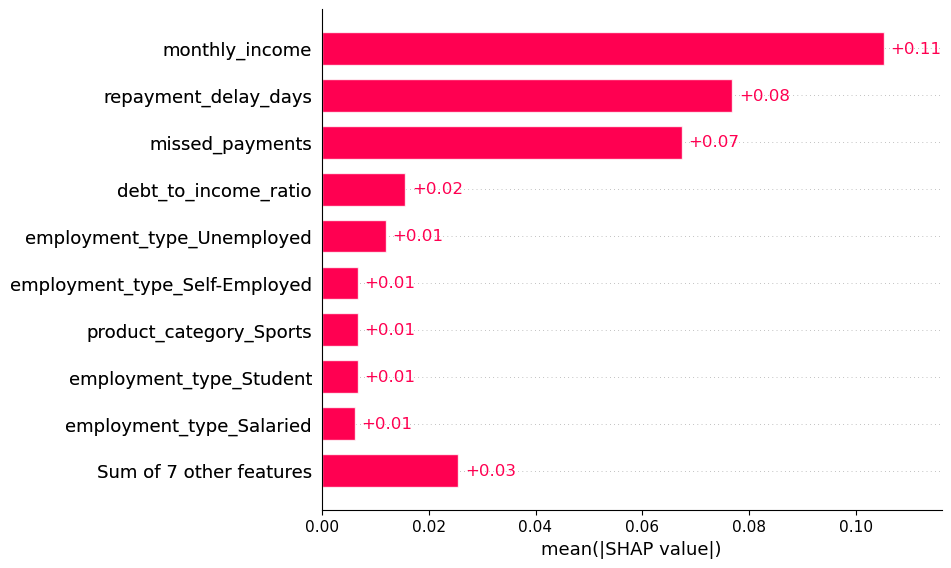

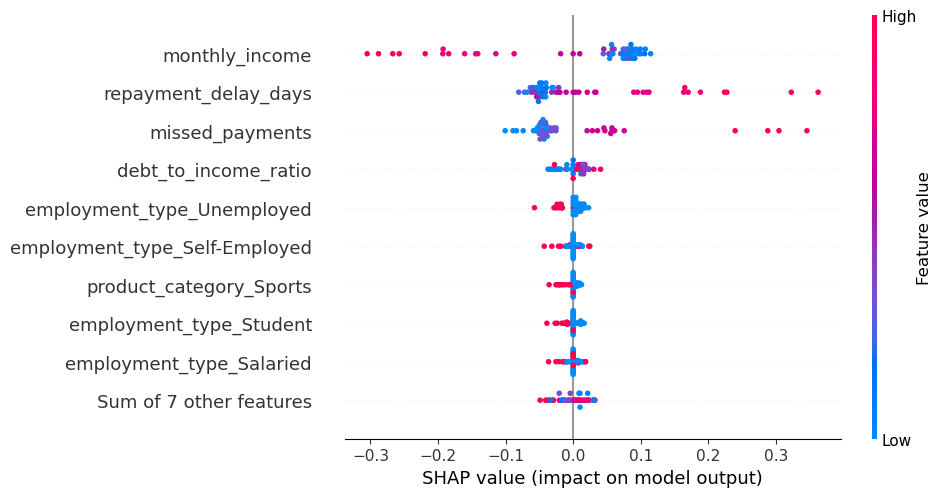

In [5]:
# 定義 DNN 模型的預測函數 (僅輸出類別 1 違約的機率)
def dnn_predict_fn(x):
    return dnn_model.predict(x, verbose=0).flatten()

# 從測試集中抽取 100 筆作為 KernelExplainer 的背景資料 (Background dataset)
X_dnn_bg = shap.sample(X_test_dnn, 100, random_state=42)

# 抽取 50 筆樣本進行解釋
X_dnn_explain = shap.sample(X_test_dnn, 50, random_state=42)

# 初始化 KernelExplainer
explainer_dnn = shap.KernelExplainer(dnn_predict_fn, X_dnn_bg)

# 計算 SHAP values (此步驟可能會稍微耗時約數十秒至一分鐘)
shap_values_dnn_raw = explainer_dnn.shap_values(X_dnn_explain)

# 整理基準值與 SHAP 值，確保皆為適合 Explanation 物件的 numpy array
shap_values_dnn_array = shap_values_dnn_raw
if isinstance(shap_values_dnn_raw, list):
    # 若模型被視為多輸出，則取對應的 class 1 (如果是長度為 2 的 list，取 index 1；否則取 index 0)
    shap_values_dnn_array = shap_values_dnn_raw[1] if len(shap_values_dnn_raw) == 2 else shap_values_dnn_raw[0]

shap_values_dnn_array = np.array(shap_values_dnn_array)

base_value = explainer_dnn.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1] if len(base_value) == 2 else base_value[0]

# 為了解決 beeswarm 等繪圖切片時的 AttributeError/TypeError，
# 將 base_value 展開為與樣本數相同長度的 1D array
num_samples = X_dnn_explain.shape[0]
base_values_array = np.full(num_samples, base_value)

# 將計算出來的 numpy array 包裝成 SHAP Explanation 物件，以利直接繪圖
shap_values_dnn = shap.Explanation(
    values=shap_values_dnn_array,
    base_values=base_values_array,
    data=X_dnn_explain.values,
    feature_names=X_test_dnn.columns.tolist()
)

# 繪製條形圖 (Bar Plot) - 全局特徵重要性
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_dnn)

# 繪製蜂巢圖 (Beeswarm Plot) - 特徵高低值對決策的影響
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_dnn)